In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


In [3]:
#datadts

X =6 * np.random.rand(100,1) - 3
y= 0.5 * X**2 + 1.5*X + 2 + np.random.randn(100, 1)

# quadratic equation y=0.5x^2+1.5x+2+outliers

Text(0, 0.5, 'Y dataset')

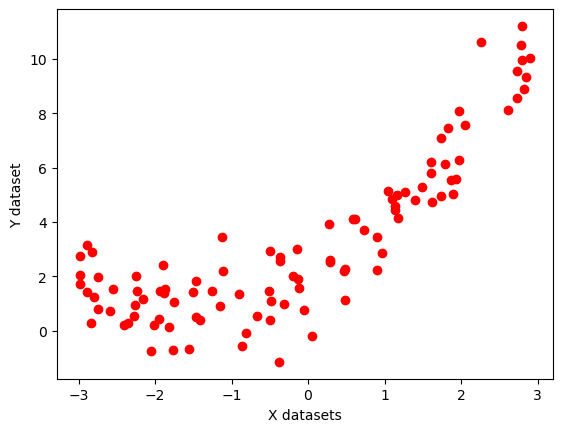

In [8]:
plt.scatter(X,y, color='r')
plt.xlabel('X datasets')
plt.ylabel('Y dataset')

In [9]:
# Train Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=42)

In [10]:
#lets implement Simp[le Linear Regression 
from sklearn.linear_model import LinearRegression
regression_1 = LinearRegression()

In [11]:
regression_1.fit(X_train, y_train)

LinearRegression()

In [12]:
from sklearn.metrics import r2_score
score= r2_score(y_test, regression_1.predict(y_test))
print(score)

-2.4195870483402255


Text(0, 0.5, 'Y dataset')

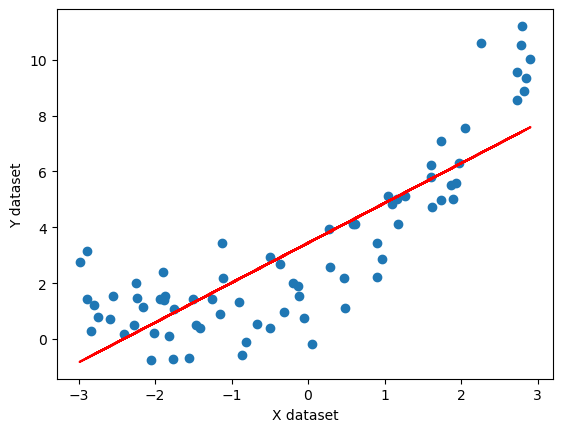

In [13]:
#Lets  visualize this model
plt.plot(X_train, regression_1.predict(X_train), color='r')
plt.scatter(X_train, y_train)
plt.xlabel("X dataset")
plt.ylabel("Y dataset")

In [14]:
#Lets apply Polynomial Tranformation
from sklearn.preprocessing import PolynomialFeatures


In [15]:
poly=PolynomialFeatures(degree=2, include_bias= True)
X_train_poly=poly.fit_transform(X_train)
X_test_poly=poly.fit(X_test)

In [18]:
X_test_poly


PolynomialFeatures()

In [19]:
X_test_poly

PolynomialFeatures()

In [20]:
print(X_train_poly)

[[ 1.00000000e+00 -5.03659634e-01  2.53673027e-01]
 [ 1.00000000e+00  9.67057637e-01  9.35200474e-01]
 [ 1.00000000e+00 -1.87438182e+00  3.51330721e+00]
 [ 1.00000000e+00  1.60378326e+00  2.57212074e+00]
 [ 1.00000000e+00 -6.66817591e-01  4.44645700e-01]
 [ 1.00000000e+00 -3.63881996e-01  1.32410107e-01]
 [ 1.00000000e+00  1.17802590e+00  1.38774503e+00]
 [ 1.00000000e+00 -8.17018682e-01  6.67519526e-01]
 [ 1.00000000e+00  2.82890558e+00  8.00270678e+00]
 [ 1.00000000e+00 -1.47080015e+00  2.16325309e+00]
 [ 1.00000000e+00 -2.23932225e+00  5.01456413e+00]
 [ 1.00000000e+00 -4.88771099e-02  2.38897187e-03]
 [ 1.00000000e+00 -2.83146629e+00  8.01720136e+00]
 [ 1.00000000e+00  1.26471566e+00  1.59950569e+00]
 [ 1.00000000e+00  1.60503927e+00  2.57615106e+00]
 [ 1.00000000e+00  4.97925853e-02  2.47930155e-03]
 [ 1.00000000e+00  1.05087829e+00  1.10434519e+00]
 [ 1.00000000e+00  4.77977438e-01  2.28462431e-01]
 [ 1.00000000e+00  1.96721852e+00  3.86994871e+00]
 [ 1.00000000e+00 -8.57259304e-

In [22]:
from sklearn.metrics import r2_score
regression=LinearRegression()
regression.fit(X_train_poly, y_train)
y_pred=regression.predict(X_test_poly)
score=r2_score(y_test, y_pred)
print(score)

ValueError: Expected 2D array, got scalar array instead:
array=PolynomialFeatures().
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

In [23]:
print(regression.coef_)

[[0.         1.48633543 0.4794058 ]]


In [24]:
print(regression.intercept_)

[1.91110286]


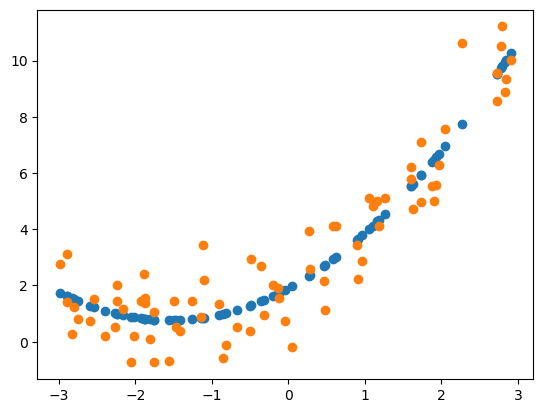

In [26]:
plt.scatter(X_train, regression.predict(X_train_poly))
plt.scatter(X_train, y_train)

In [27]:
# Prediction of New data


In [28]:
X_new= np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly= poly.transform(X_new)

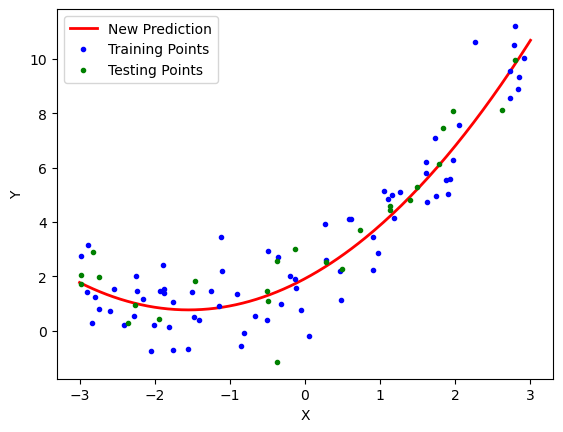

In [33]:
y_new= regression.predict(X_new_poly)
plt.plot(X_new, y_new, 'r-', linewidth=2, label='New Prediction')
plt.plot(X_train, y_train, 'b.', label='Training Points')
plt.plot(X_test, y_test, 'g.', label='Testing Points')
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

Pipeline Concepts

In [34]:
from sklearn.pipeline import Pipeline

In [35]:
def poly_regression(degree):
    X_new = np.linspace(-3, 3, 200).reshape(200, 1)
    
    poly_features=PolynomialFeatures(degree=degree,include_bias=True)
    lin_reg=LinearRegression()
    poly_regression=Pipeline([
        ("poly_features",poly_features),
        ("lin_reg",lin_reg)
    ])
    poly_regression.fit(X_train,y_train) ## ploynomial and fit of linear reression
    y_pred_new=poly_regression.predict(X_new)
    #plotting prediction line
    plt.plot(X_new, y_pred_new,'r', label="Degree " + str(degree), linewidth=2)
    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.plot(X_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-4,4, 0, 10])
    plt.show()

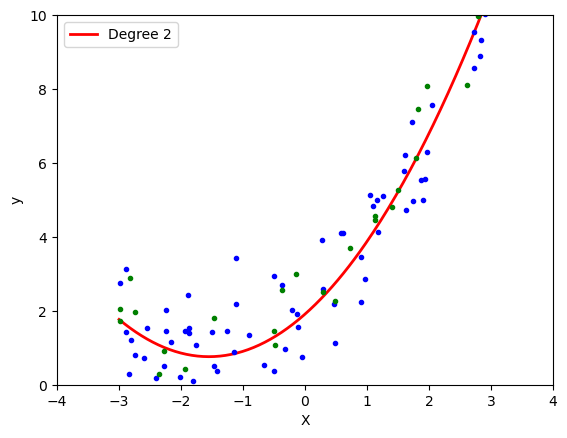

In [45]:
poly_regression(2)